# DeployDR 커리큘럼 `level` 추이 — 학습 로그 시각화

`DeployDRCurriculum` 은 단일 스칼라 `level ∈ [0,1]` 로 모든 DR 채널(센서 노이즈·push·action delay·action noise)을
동시에 조절한다 (`src/tasks/velocity/mdp/curriculums.py`). level 은 성능 EMA 에 따라 오르내린다:

- **UP** (+0.01): `timeout_ema≥0.80 AND tracking_ema≥0.75 AND fall_ema≤0.15` 가 4회 연속
- **DOWN** (−0.03): `fall_ema≥0.25` 가 2회 연속

TensorBoard 스칼라(`Curriculum/deploy_dr/*`)로 level 과 그것을 움직인 EMA, 그리고 level 에서 파생되는
각 DR 채널 강도를 함께 그린다.

비교 run: `gait01`(DeployDR-v0, foot_gait 0.1) · `gait05`(0.5) · `nodr`(level 고정 0, 대조군).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOGROOT = "logs/rsl_rl/go2_velocity"
RUNS = {
    "gait01 (w=0.1)": ("2026-05-20_16-03-43_deploy_gait01_h100_seed42", "tab:blue"),
    "gait05 (w=0.5)": ("2026-05-20_16-03-49_deploy_gait05_h100_seed42", "tab:red"),
    "nodr (level\u22610)": ("2026-05-20_13-31-17_deploydr_nodr_v0_seed42", "0.6"),
}
TAGS = ["level", "tracking_ema", "fall_rate_ema", "timeout_rate_ema"]

def load(run_dir):
    ea = EventAccumulator(f"{LOGROOT}/{run_dir}", size_guidance={"scalars": 0}); ea.Reload()
    out = {}
    for t in TAGS:
        s = ea.Scalars(f"Curriculum/deploy_dr/{t}")
        out[t] = (np.array([x.step for x in s]), np.array([x.value for x in s]))
    return out

data = {name: load(d) for name, (d, _) in RUNS.items()}
COL = {name: c for name, (_, c) in RUNS.items()}
print({k: len(v["level"][1]) for k, v in data.items()})

{'gait01 (w=0.1)': 5000, 'gait05 (w=0.5)': 5000, 'nodr (level≡0)': 2000}


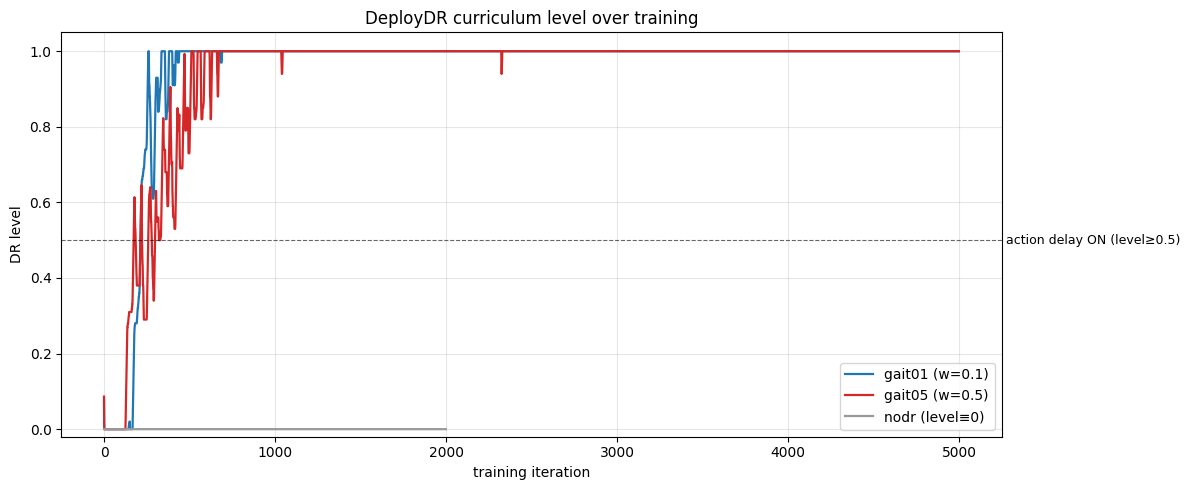

In [3]:
# ── 1. level vs iteration ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for name in RUNS:
    st, v = data[name]["level"]
    ax.plot(st, v, color=COL[name], lw=1.6, label=name)
ax.axhline(0.5, ls="--", c="k", lw=0.8, alpha=0.6)
ax.text(ax.get_xlim()[1], 0.5, " action delay ON (level\u22650.5)", va="center", fontsize=9)
ax.set_xlabel("training iteration"); ax.set_ylabel("DR level")
ax.set_ylim(-0.02, 1.05); ax.grid(alpha=0.3); ax.legend(loc="lower right")
ax.set_title("DeployDR curriculum level over training")
fig.tight_layout(); plt.show()

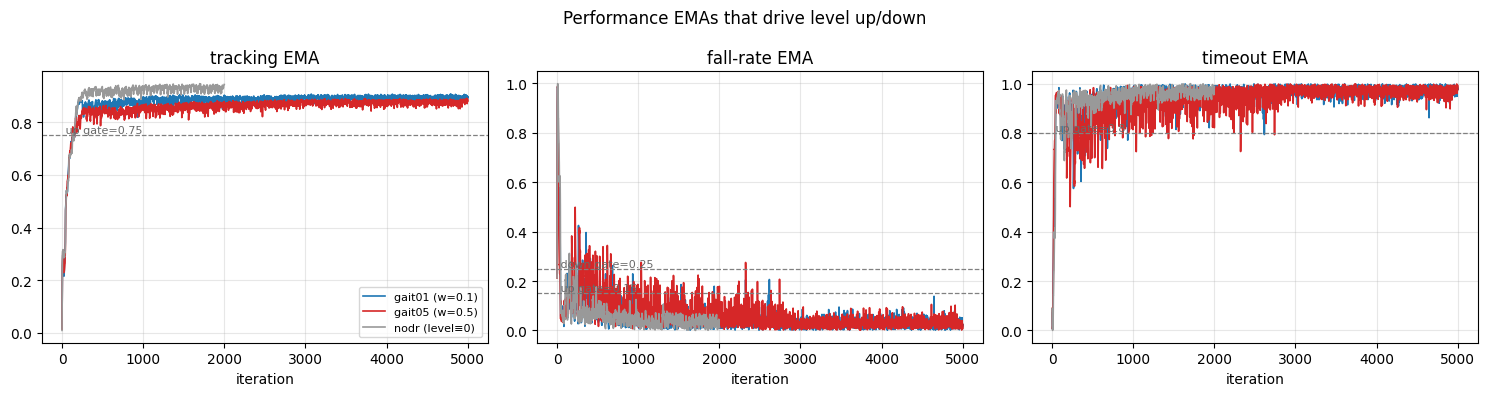

In [4]:
# ── 2. level 을 움직인 성능 EMA (gate 임계선 표시) ─────────────────────────
panels = [("tracking_ema", "tracking EMA", [(0.75, "up gate")]),
          ("fall_rate_ema", "fall-rate EMA", [(0.15, "up gate"), (0.25, "down gate")]),
          ("timeout_rate_ema", "timeout EMA", [(0.80, "up gate")])]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, (tag, ttl, gates) in zip(axes, panels):
    for name in RUNS:
        st, v = data[name][tag]
        ax.plot(st, v, color=COL[name], lw=1.2, label=name)
    for gy, gl in gates:
        ax.axhline(gy, ls="--", c="gray", lw=0.9)
        ax.text(0, gy, f" {gl}={gy}", fontsize=8, va="bottom", color="dimgray")
    ax.set_title(ttl); ax.set_xlabel("iteration"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.suptitle("Performance EMAs that drive level up/down")
fig.tight_layout(); plt.show()

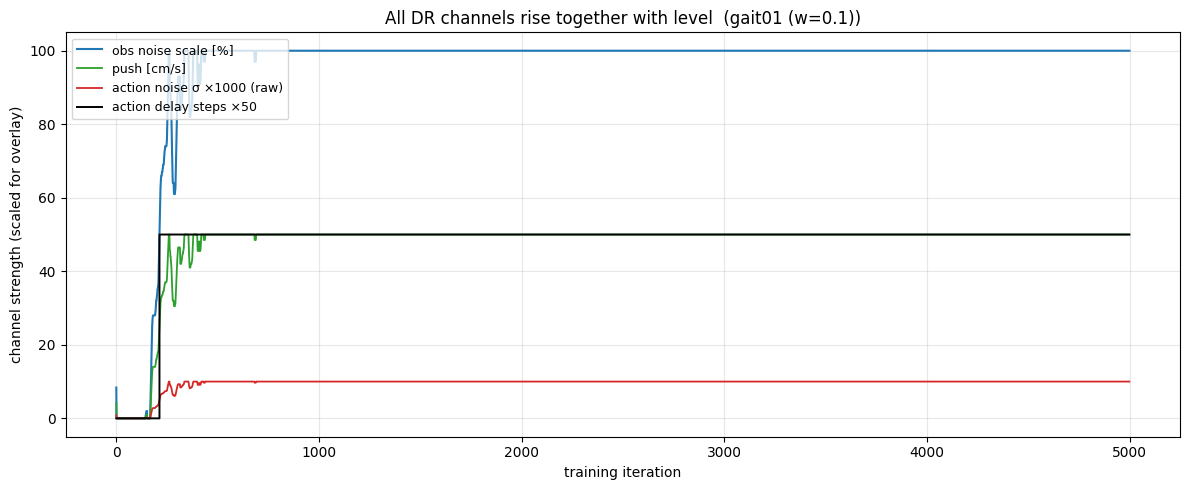

action delay turns ON at iteration: 213 (level first ≥ 0.5)


In [5]:
# ── 3. level 에서 파생되는 각 DR 채널 강도 (모두 같은 level 에 종속) ───────
#   obs noise   = 1.0 * level     (max_obs_noise_scale=1.0)
#   push [m/s]  = 0.5 * level     (max_push=0.5)
#   delay steps = round(1*level)  (delay_max_steps=1)  -> level>=0.5 에서 0->1
#   noise std   = 0.1 * level     (noise_std_max=0.1)
name = "gait01 (w=0.1)"   # 대표 run
st, lv = data[name]["level"]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(st, 100 * lv, color="tab:blue", lw=1.5, label="obs noise scale [%]")
ax.plot(st, 0.5 * lv * 100, color="tab:green", lw=1.3, label="push [cm/s]")
ax.plot(st, 0.1 * lv * 100, color="tab:red", lw=1.3, label="action noise \u03c3 \u00d71000 (raw)")
ax.step(st, np.round(lv).astype(int) * 50, where="post", color="k", lw=1.4, label="action delay steps \u00d750")
ax.set_xlabel("training iteration"); ax.set_ylabel("channel strength (scaled for overlay)")
ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=9)
ax.set_title(f"All DR channels rise together with level  ({name})")
fig.tight_layout(); plt.show()

delay_on = st[np.argmax(np.round(lv).astype(int) >= 1)] if (np.round(lv) >= 1).any() else None
print("action delay turns ON at iteration:", delay_on, "(level first \u2265 0.5)")

## 읽는 법
- **그림 1**: level 이 0 → 1.0 으로 단조에 가깝게 상승하면 정책이 교란을 잘 흡수하는 것. 점선(level=0.5)을 넘는 순간부터 action delay(1 step=20ms)가 켜진다.
- **그림 2**: level 을 올린 원동력. tracking EMA 가 0.75 위, fall EMA 가 0.15 아래, timeout EMA 가 0.80 위를 동시에 4회 연속 유지하면 level↑. fall EMA 가 0.25 위로 튀면 level↓(−0.03, 빠른 후퇴).
- **그림 3**: 단일 level 손잡이 하나로 센서 노이즈·push·delay·action noise 가 **함께** 세진다(종속). delay 만 계단식(level≥0.5).
- **nodr**: level_max=0 이라 평생 0 → DR off 대조군.